# 06 · First call to the Global Fishing Watch API

**Module 6, session 1** · 2026-10-02
First step of the exit test: connect to the GFW API from Python and get real data back.

## Vocabulary

| Term | In my words | In this notebook |
|---|---|---|
| **API** | A way for two pieces of software to talk to each other and exchange stuff. | The GFW API, called through `gfw-api-python-client`. |
| **Endpoint** | A specific place in an API where you ask for one particular thing. | `vessels.search_vessels`. Others: Events, 4Wings (fishing effort). |
| **Token** | A digital key that proves who you are and what you're allowed to access. | Stored in Colab Secrets as `GFW_API_ACCESS_TOKEN`, never in the code. |
| **JSON** | A simple, structured way of packaging data so different systems can understand it. | The response. Nested, so `.df()` only flattens the top level. |

## First finding

Searching one MMSI (`412331038`) returned **5 vessel identities**, and only one of them matches official registries: *LU PENG YUAN YU 019*, a 69.9 m Chinese squid jigger. MMSI is self-reported and not unique, so any feature that counts vessels has to say which identity it uses (MMSI or GFW `vessel_id`).

In [ ]:
   !pip install gfw-api-python-client

In [ ]:
from google.colab import userdata
import gfwapiclient as gfw

token = userdata.get("GFW_API_ACCESS_TOKEN")
print(len(token))

gfw_client = gfw.Client(access_token=token)

806


In [ ]:
result = await gfw_client.vessels.search_vessels(query="412331038")
df = result.df()
df.head()

,dataset,registry_info_total_records,registry_info,registry_owners,registry_public_authorizations,combined_sources_info,self_reported_info,matchCriteria
0,public-global-vessel-identity:v4.0,0,[],[],[],[{'vessel_id': '108c5510b-b6aa-9cf2-8b86-0598d...,[{'id': '108c5510b-b6aa-9cf2-8b86-0598de546741...,[{'reference': '108c5510b-b6aa-9cf2-8b86-0598d...
1,public-global-vessel-identity:v4.0,0,[],[],[],[{'vessel_id': 'd2fbd05f5-57dd-1faa-c384-67a75...,[{'id': 'd2fbd05f5-57dd-1faa-c384-67a75f27fc80...,[{'reference': 'd2fbd05f5-57dd-1faa-c384-67a75...
2,public-global-vessel-identity:v4.0,0,[],[],[],[{'vessel_id': 'a5ef97d59-9f40-3bdc-e247-daf9c...,[{'id': 'a5ef97d59-9f40-3bdc-e247-daf9c892ceff...,[{'reference': 'a5ef97d59-9f40-3bdc-e247-daf9c...
3,public-global-vessel-identity:v4.0,0,[],[],[],[{'vessel_id': '91df2f8c7-74fd-5b5a-60f5-3d86f...,[{'id': '91df2f8c7-74fd-5b5a-60f5-3d86f9c51ff2...,[{'reference': '91df2f8c7-74fd-5b5a-60f5-3d86f...
4,public-global-vessel-identity:v4.0,1,"[{'id': '4ef90bea19300c6a23f6ce627a80238b', 's...","[{'name': 'ZHOUSHAN SHUNHANG OCEAN FISHERIES',...","[{'date_from': 2017-01-04 00:00:00+00:00, 'dat...",[{'vessel_id': '755a48dd4-4bee-4bcf-7b5f-9baea...,[{'id': '755a48dd4-4bee-4bcf-7b5f-9baea058fc7b...,[{'reference': '755a48dd4-4bee-4bcf-7b5f-9baea...


In [ ]:
from shapely.geometry import box, mapping
area = mapping(box(-4.1, 36.55, -3.3, 36.80))

effort = await gfw_client.fourwings.create_fishing_effort_report(
    spatial_resolution="HIGH",
    temporal_resolution="MONTHLY",
    group_by="FLAG",
    start_date="2025-01-01",
    end_date="2025-12-31",
    geojson=area,
)
df_effort = effort.df()
df_effort.head()

,date,detections,flag,gear_type,hours,vessel_ids,vessel_id,vessel_type,entry_timestamp,exit_timestamp,first_transmission_date,last_transmission_date,imo,mmsi,call_sign,dataset,report_dataset,ship_name,lat,lon
0,2025-01,None,ESP,None,1.993056,1,None,None,None,None,None,None,None,None,None,None,public-global-fishing-effort:v4.0,None,36.69,-3.80
1,2025-10,None,ESP,None,5.788889,4,None,None,None,None,None,None,None,None,None,None,public-global-fishing-effort:v4.0,None,36.63,-3.75
2,2025-10,None,ESP,None,2.911389,3,None,None,None,None,None,None,None,None,None,None,public-global-fishing-effort:v4.0,None,36.65,-3.69
3,2025-07,None,ESP,None,0.989722,1,None,None,None,None,None,None,None,None,None,None,public-global-fishing-effort:v4.0,None,36.62,-3.72
4,2025-06,None,ESP,None,2.000833,2,None,None,None,None,None,None,None,None,None,None,public-global-fishing-effort:v4.0,None,36.64,-3.87


In [ ]:
print(len(df_effort), "rows")
print(df_effort.columns.tolist())
print(round(df_effort["hours"].sum()), "fishing hours in total")
df_effort["flag"].value_counts()

7033 rows
['date', 'detections', 'flag', 'gear_type', 'hours', 'vessel_ids', 'vessel_id', 'vessel_type', 'entry_timestamp', 'exit_timestamp', 'first_transmission_date', 'last_transmission_date', 'imo', 'mmsi', 'call_sign', 'dataset', 'report_dataset', 'ship_name', 'lat', 'lon']
23183 fishing hours in total


,count
flag,
ESP,7023
USA,6
BEL,3
GBR,1


In [ ]:
df_effort.groupby("flag")["hours"].sum().sort_values(ascending=False)

,hours
flag,
ESP,23162.502500
BEL,14.597500
USA,4.523611
GBR,1.007222


## Hypothesis (written before looking at the data)

**I expect fishing effort to drop in summer (June to September).**

**Why:** summer brings tourism to the Granada coast: beaches, recreational boats, divers, more eyes on the water. With more people around, fishing vessels are more likely to be seen in places they shouldn't be (too close to shore, near the reserve). That risk might push fleets to fish less here in summer, or to fish elsewhere.

**What would support it:**
- A clear dip in fishing hours in the summer months.
- The dip is stronger close to shore than offshore (testable later with `lat` and `lon`).

**What else could explain a summer dip:**
- **Seasonal closures:** fishing bans set by regulation for some fleets and months.
- **Fish availability:** target species move or change with the season.
- **AIS switched off:** a vessel that doesn't want to be seen can stop broadcasting. In this data, *fewer vessels* and *vessels gone dark* look identical. GFW data alone can't tell them apart.

In [ ]:
monthly = df_effort.groupby("date")["hours"].sum().round(0)
monthly

,hours
date,
2025-01,1847.0
2025-02,1205.0
2025-03,1884.0
2025-04,2254.0
2025-05,1620.0
2025-06,2366.0
2025-07,2521.0
2025-08,2069.0
2025-09,1362.0


Text(0, 0.5, 'Fishing hours')

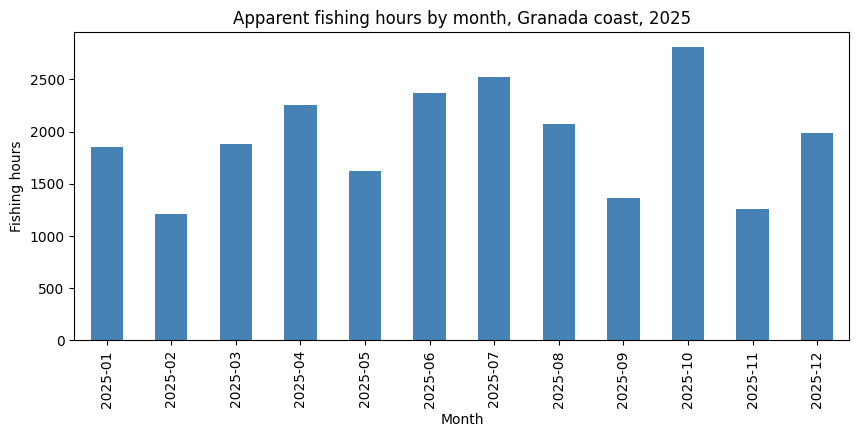

In [ ]:
ax = monthly.plot(kind="bar", figsize=(10, 4), color="steelblue")
ax.set_title("Apparent fishing hours by month, Granada coast, 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Fishing hours")

## Answer

**The prediction does not hold at coast scale.** Fishing effort in the box does not drop in summer. June and July are among the busiest months of 2025 (about 2,370 and 2,520 hours), second only to October (about 2,810). Summer (June to September) averages about 2,080 hours a month, against about 1,860 for the rest of the year.

The pattern looks more like **irregular dips** than a season: February, May, September and November are the low months (about 1,200 to 1,600 hours).

**What this does not rule out:** the hypothesis was really about fishing *close to shore*, where tourists are. This chart adds up the whole box, out to about 25 km offshore. Effort could still shift away from the beaches in summer while staying the same in total. That needs the `lat` and `lon` columns: next step.

**How much I trust it:** moderately. One year only, so no proof of a repeating pattern. Only vessels with AIS (mostly 15 m or longer), so the small inshore boats my hypothesis cares about most are largely missing. And "fishing hours" is GFW's model estimate from vessel movement, not a logbook.

## Detour: does fishing effort follow closures and sea conditions?

**Three things can stop a boat going out:**

1. **Regulation.** Closures ("paradas biológicas") keep trawlers in port to let stocks recover. Almería's trawl fleet stopped from 1 Feb to 5 Mar 2025. In 2024 the stop covered Almería *and* Granada (1 to 29 Feb), so a February 2025 stop for Motril is likely but **not confirmed**. On 2 Jan 2025, Andalusian trawlers also stayed in port in protest at EU cuts to Mediterranean fishing days.
2. **Weather.** Rough seas keep boats in port. I measure this as **days per month with maximum wave height of 2 m or more**, offshore of Punta de la Mona (Open-Meteo Marine API). The 2 m threshold is my assumption, not a regulatory rule.
3. **Biology and markets.** Fish move with the seasons and prices change. Not measured here.

**Predictions:**
- February is low (closure).
- Months with more rough days have fewer fishing hours.

**Chart choice:** two panels sharing the month axis, not one chart with two y-axes. With two axes, the scale you pick can create a correlation that isn't there.

In [ ]:
import requests
import pandas as pd

url = "https://marine-api.open-meteo.com/v1/marine"
params = {
    "latitude": 36.65,
    "longitude": -3.72,
    "daily": "wave_height_max",
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "timezone": "Europe/Madrid",
}
response = requests.get(url, params=params)
response.raise_for_status()

waves = pd.DataFrame(response.json()["daily"])
waves["time"] = pd.to_datetime(waves["time"])
waves.head()

,time,wave_height_max
0,2025-01-01,0.86
1,2025-01-02,0.72
2,2025-01-03,0.58
3,2025-01-04,0.80
4,2025-01-05,0.66


In [ ]:
waves["month"] = waves["time"].dt.strftime("%Y-%m")
rough_days = (waves["wave_height_max"] >= 2.0).groupby(waves["month"]).sum()

combined = pd.DataFrame({
    "fishing_hours": monthly,
    "rough_days": rough_days,
})
combined

,fishing_hours,rough_days
2025-01,1847.0,1
2025-02,1205.0,0
2025-03,1884.0,3
2025-04,2254.0,4
2025-05,1620.0,0
2025-06,2366.0,0
2025-07,2521.0,0
2025-08,2069.0,1
2025-09,1362.0,0
2025-10,2813.0,0


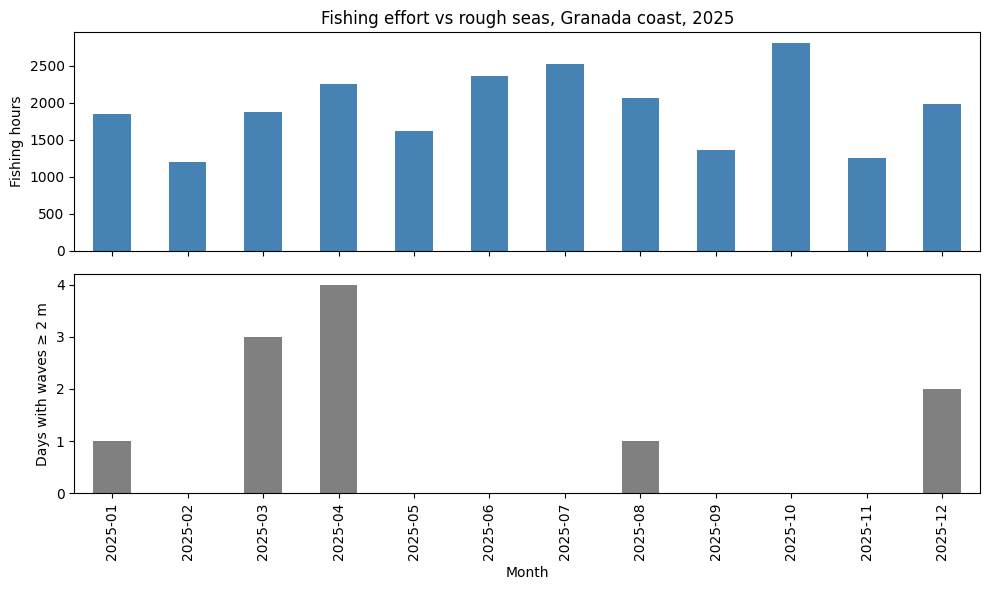

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

combined["fishing_hours"].plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_ylabel("Fishing hours")
ax1.set_title("Fishing effort vs rough seas, Granada coast, 2025")

combined["rough_days"].plot(kind="bar", ax=ax2, color="grey")
ax2.set_ylabel("Days with waves ≥ 2 m")
ax2.set_xlabel("Month")

plt.tight_layout();

In [ ]:
r = combined["fishing_hours"].corr(combined["rough_days"])
print(round(r, 2))

0.17


## Answer: closures fit better than weather

**Weather does not explain the monthly pattern.** Correlation between fishing hours and rough days is **r = 0.17**: weak, and in the opposite direction to the prediction. Waves reached 2 m on only 11 days in 2025, never more than 4 in a month. A measure that barely changes cannot explain big monthly swings. April had the most rough days and was one of the busiest months.

**The low months (February, May, September, November) all had calm seas.** Something other than waves keeps boats in port.

**February fits the regulation explanation:** calm sea, low effort, in the month when Granada's trawlers stopped in 2024 (unconfirmed for 2025).

**A new hypothesis (not tested):** in 2025 the EU capped how many days trawlers may fish in the Mediterranean. If days are rationed, effort becomes a budget the fleet spends across the year, and the monthly pattern may follow how many days are left rather than sea conditions.

**Limits of this test:**
- **Monthly totals hide short storms.** A 3-day storm disappears inside a month of fishing. A fair test compares *daily* fishing hours with *daily* wave height.
- **The 2 m threshold is my guess.** Smaller boats may stay in port with lower waves.
- **One wave point**, about 8 km offshore, stands for the whole coast.
- **12 months of data** can't prove anything, only hint.

In [31]:
import zipfile
import geopandas as gpd

zipfile.ZipFile("WDPA_WDOECM_Sep2026_Public_555523929.zip").extractall("wdpa")
mpa = gpd.read_file(
    "wdpa/WDPA_WDOECM_Sep2026_Public_555523929.gdb",
    layer="WDPA_WDOECM_poly_Sep2026_555523929",
)
mpa[["NAME", "GIS_AREA"]]

,NAME,GIS_AREA
0,Acantilados y Fondos Marinos de La Punta de La...,1.250058


In [32]:
cells = df_effort.groupby(["lat", "lon"])["hours"].sum().reset_index()
cells_gdf = gpd.GeoDataFrame(
    cells,
    geometry=gpd.points_from_xy(cells["lon"], cells["lat"]),
    crs="EPSG:4326",
)
print(len(cells_gdf), "cells")
cells_gdf["hours"].describe()

1086 cells


,hours
count,1086.000000
mean,21.346806
std,21.981114
min,0.008333
25%,5.567222
50%,14.830000
75%,32.064861
max,282.966389


In [38]:
m = cells_gdf.explore(
    column="hours",
    cmap="YlOrRd",
    tiles="Esri.WorldImagery",
    marker_kwds={"radius": 4},
    tooltip=["hours"],
)
mpa.explore(m=m, color="cyan", style_kwds={"fill": False, "weight": 3})
m

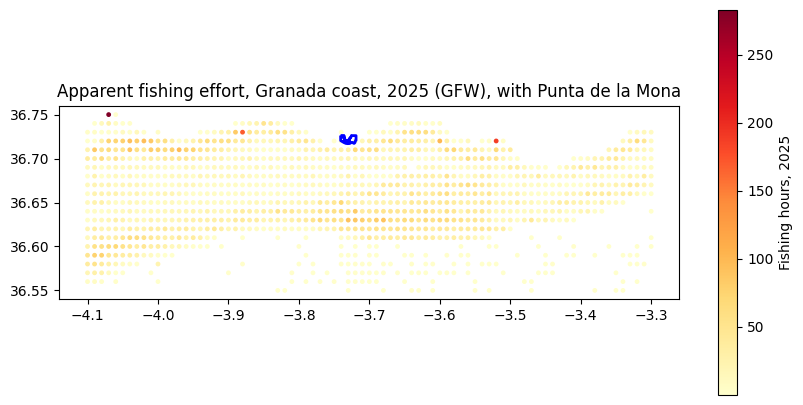

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
cells_gdf.plot(ax=ax, column="hours", cmap="YlOrRd", markersize=6,
               legend=True, legend_kwds={"label": "Fishing hours, 2025"})
mpa.boundary.plot(ax=ax, color="blue", linewidth=2)
ax.set_title("Apparent fishing effort, Granada coast, 2025 (GFW), with Punta de la Mona")
fig.savefig("06_fishing_effort_map.png", dpi=150, bbox_inches="tight");

In [41]:
near = mpa.to_crs(25830).buffer(1000).to_crs(4326).union_all()
cells_near = cells_gdf[cells_gdf.within(near)]

hours_near = cells_near["hours"].sum()
hours_total = cells_gdf["hours"].sum()
share = hours_near / hours_total * 100

print(len(cells_near), "cells within 1 km of the reserve")
print(round(hours_near, 1), "hours, out of", round(hours_total), "in the whole box")
print(round(share, 2), "% of the box's fishing effort")

8 cells within 1 km of the reserve
153.1 hours, out of 23183 in the whole box
0.66 % of the box's fishing effort
